# 04 · Signal & image-processing analysis of CirCor PCG (24AIM301 Units 1–4)

| Syllabus topic | Where it is used in the project |
|---|---|
| Noises, IIR vs FIR filters | 20–800 Hz Butterworth (IIR) vs Hamming-window FIR: magnitude, phase, group delay, cost |
| Power spectral density | Welch PSD by murmur class and by band → motivates the RL band choices |
| Cross-spectral density & coherence | Magnitude-squared coherence between auscultation sites of the same patient |
| Cepstrum & homomorphic filtering | Homomorphic envelogram + cepstral heart rate (validated against TSV heart rate) |
| Fourier & wavelet transforms | STFT vs wavelet-packet time–frequency images (Notebook 05) |
| PCA / ICA | PCA of state descriptors (RL state); FastICA separating PCG from an interfering source |
| Image enhancement / segmentation | Histogram equalisation + Otsu thresholding of the scalogram image |
| Feature extraction (texture) | GLCM texture of time–frequency images, systolic-vs-diastolic energy maps |
| Image compression | JPEG-style DCT coding of TF images — accuracy vs bits/pixel (Notebook 18) |

In [1]:
%run common/00_config.ipynb
%run common/01_signal_lib.ipynb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import roc_auc_score
import timeit

df = pd.read_csv(P["metadata"] / "records_qc.csv")
df = df[df.qc_keep].reset_index(drop=True)
sig = np.load(P["segments"] / "signals.npz")
fs = CFG["preprocessing"]["fs"]
lab = df[df.murmur_label.isin(["Present", "Absent"])]

ROOT = C:\Users\roshh\Desktop\rl
CirCor version = 1.0.3


loaded 01_signal_lib


## 1. IIR (Butterworth) vs FIR band-pass 20–800 Hz

C:\Users\roshh\AppData\Local\Temp\ipykernel_2932\2145125913.py:7: UserWarning: The filter's denominator is extremely small at frequencies [0.000], around which a singularity may be present
  _, gd_iir = sps.group_delay((b_iir, a_iir), 4096, fs=fs)


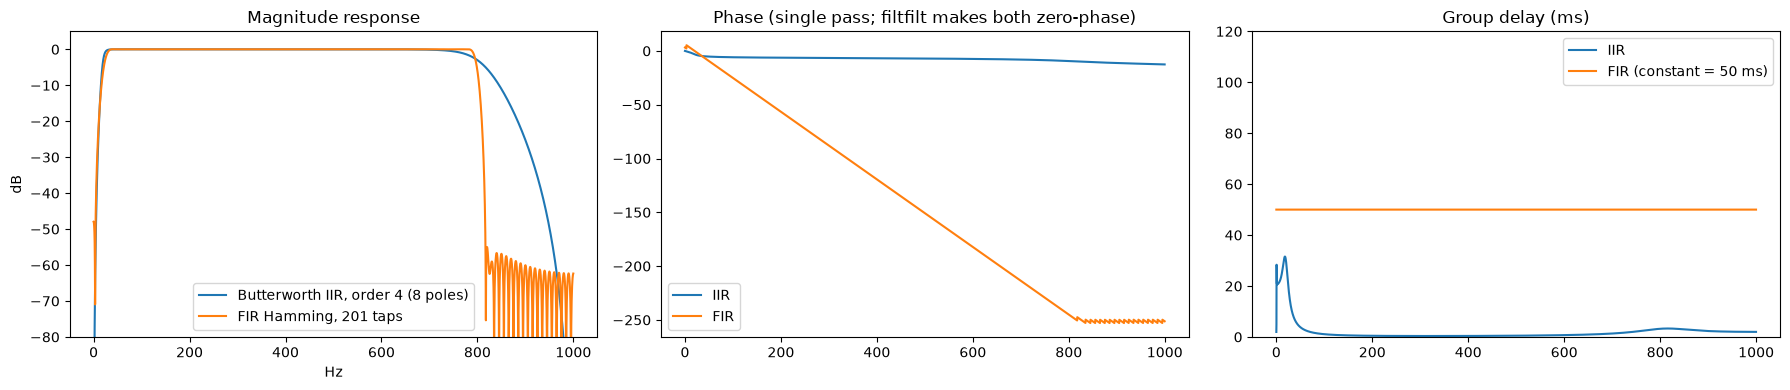

,filter,coefficients,mults/sample (one pass),time per recording (ms)
0,Butterworth IIR (SOS),24,20,1.32436
1,FIR Hamming,201,201,2.34418


In [2]:
sos = butter_bandpass_sos(20, 800, fs, 4)
taps = fir_bandpass(20, 800, fs, 201)
w, h_iir = sps.sosfreqz(sos, 4096, fs=fs)
_, h_fir = sps.freqz(taps, 1, 4096, fs=fs)
_, gd_fir = sps.group_delay((taps, 1), 4096, fs=fs)
b_iir, a_iir = sps.sos2tf(sos)
_, gd_iir = sps.group_delay((b_iir, a_iir), 4096, fs=fs)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(w, 20 * np.log10(np.abs(h_iir) + 1e-12), label="Butterworth IIR, order 4 (8 poles)")
ax[0].plot(w, 20 * np.log10(np.abs(h_fir) + 1e-12), label="FIR Hamming, 201 taps")
ax[0].set_ylim(-80, 5); ax[0].set_xlabel("Hz"); ax[0].set_ylabel("dB"); ax[0].legend(); ax[0].set_title("Magnitude response")
ax[1].plot(w, np.unwrap(np.angle(h_iir)), label="IIR"); ax[1].plot(w, np.unwrap(np.angle(h_fir)), label="FIR")
ax[1].set_title("Phase (single pass; filtfilt makes both zero-phase)"); ax[1].legend()
ax[2].plot(w, gd_iir / fs * 1000, label="IIR"); ax[2].plot(w, gd_fir / fs * 1000, label="FIR (constant = 50 ms)")
ax[2].set_ylim(0, 120); ax[2].set_title("Group delay (ms)"); ax[2].legend()
plt.tight_layout(); savefig(fig, "04_iir_vs_fir"); plt.show()

x = sig[lab.record_id.iloc[0]].astype(np.float32)
t_iir = min(timeit.repeat(lambda: bandpass(x, 20, 800, fs, 4, "iir"), number=5, repeat=3)) / 5
t_fir = min(timeit.repeat(lambda: bandpass(x, 20, 800, fs, 4, "fir"), number=5, repeat=3)) / 5
filt_tab = pd.DataFrame({"filter": ["Butterworth IIR (SOS)", "FIR Hamming"], "coefficients": [sos.size, taps.size],
                         "mults/sample (one pass)": [5 * sos.shape[0], taps.size],
                         "time per recording (ms)": [t_iir * 1e3, t_fir * 1e3]})
filt_tab.to_csv(P["tables"] / "04_filter_comparison.csv", index=False)
filt_tab

## 2. Welch PSD by murmur class, and class separation per frequency band

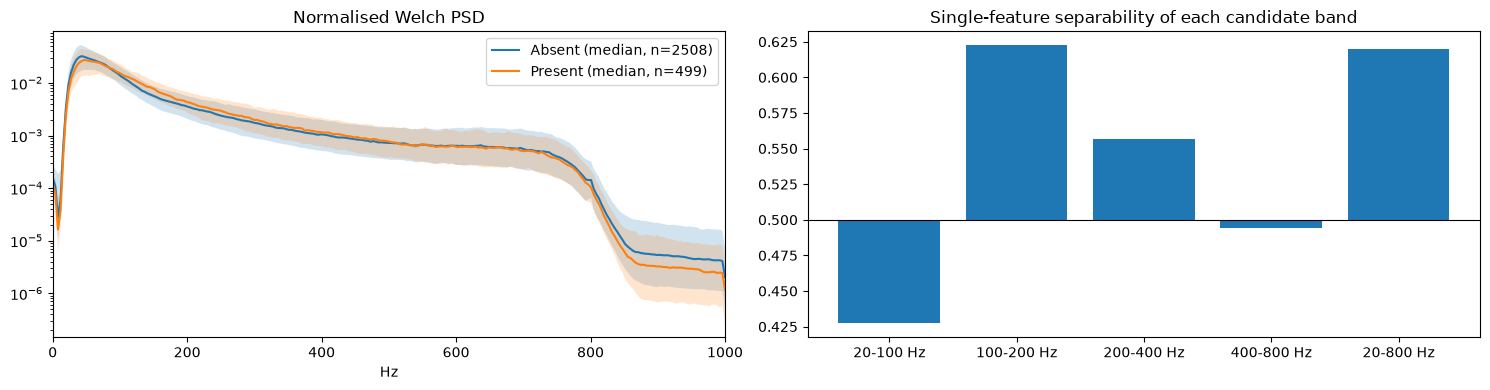

,band,AUROC of relative band power,higher in
0,20-100 Hz,0.427509,Absent
1,100-200 Hz,0.622564,Present
2,200-400 Hz,0.556754,Present
3,400-800 Hz,0.493922,Absent
4,20-800 Hz,0.619879,Present


In [3]:
def psd_of(rid):
    f, p = welch_psd(sig[rid].astype(np.float32), fs, 512)
    return f, p / p.sum()


f, _ = psd_of(lab.record_id.iloc[0])
psd = {c: np.stack([psd_of(r)[1] for r in lab.record_id[lab.murmur_label == c]]) for c in ["Absent", "Present"]}
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for c, arr in psd.items():
    m = np.median(arr, 0)
    ax[0].semilogy(f, m, label=f"{c} (median, n={len(arr)})")
    ax[0].fill_between(f, np.percentile(arr, 25, 0), np.percentile(arr, 75, 0), alpha=0.2)
ax[0].set_xlim(0, 1000); ax[0].legend(); ax[0].set_title("Normalised Welch PSD"); ax[0].set_xlabel("Hz")
bands = CFG["actions"]["band"]
rows = []
for lo, hi in bands:
    m = (f >= lo) & (f < hi)
    e = np.concatenate([np.log(psd["Absent"][:, m].sum(1)), np.log(psd["Present"][:, m].sum(1))])
    y = np.r_[np.zeros(len(psd["Absent"])), np.ones(len(psd["Present"]))]
    a = roc_auc_score(y, e)
    rows.append({"band": f"{lo}-{hi} Hz", "AUROC of relative band power": a, "higher in": "Present" if a > 0.5 else "Absent"})
bt = pd.DataFrame(rows)
ax[1].bar(bt.band, bt["AUROC of relative band power"] - 0.5, bottom=0.5)
ax[1].axhline(0.5, color="k", lw=0.8); ax[1].set_title("Single-feature separability of each candidate band")
plt.tight_layout(); savefig(fig, "04_psd_by_class"); plt.show()
bt

## 3. Homomorphic envelogram and cepstral heart rate (validated against TSV annotations)

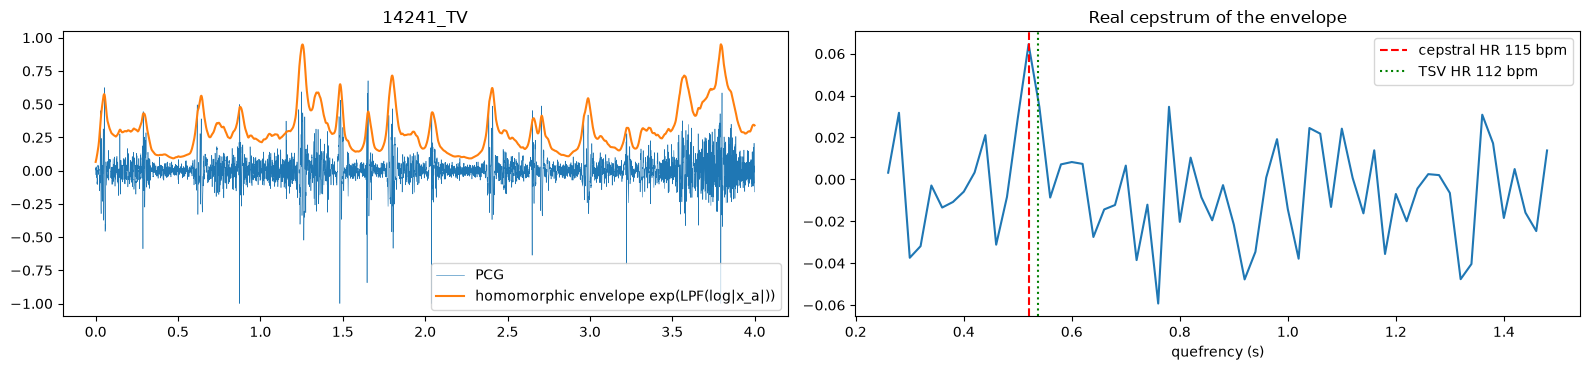

In [4]:
ex = lab[lab.murmur_label == "Present"].iloc[3]
x = sig[ex.record_id].astype(np.float32)
env = homomorphic_envelope(x, fs)
fs_e = 50
e50 = sps.resample_poly(env, fs_e, fs); e50 = e50 - e50.mean()
spec = np.abs(np.fft.rfft(e50 * np.hanning(len(e50)), n=4 * len(e50))) + 1e-8
ceps = np.fft.irfft(np.log(spec)); q = np.arange(len(ceps)) / fs_e
fig, ax = plt.subplots(1, 2, figsize=(16, 3.8))
t = np.arange(len(x)) / fs
ax[0].plot(t[: 4 * fs], x[: 4 * fs] / np.abs(x).max(), lw=0.4, label="PCG")
ax[0].plot(t[: 4 * fs], env[: 4 * fs] / env.max(), lw=1.5, label="homomorphic envelope exp(LPF(log|x_a|))")
ax[0].legend(); ax[0].set_title(ex.record_id)
m = (q > 0.25) & (q < 1.5)
ax[1].plot(q[m], ceps[m]); ax[1].set_xlabel("quefrency (s)")
bpm, prom = cepstral_heart_rate(x, fs)
ax[1].axvline(60 / bpm, color="r", ls="--", label=f"cepstral HR {bpm:.0f} bpm")
ax[1].axvline(60 / ex.heart_rate_tsv, color="g", ls=":", label=f"TSV HR {ex.heart_rate_tsv:.0f} bpm")
ax[1].legend(); ax[1].set_title("Real cepstrum of the envelope")
plt.tight_layout(); savefig(fig, "04_homomorphic_cepstrum"); plt.show()

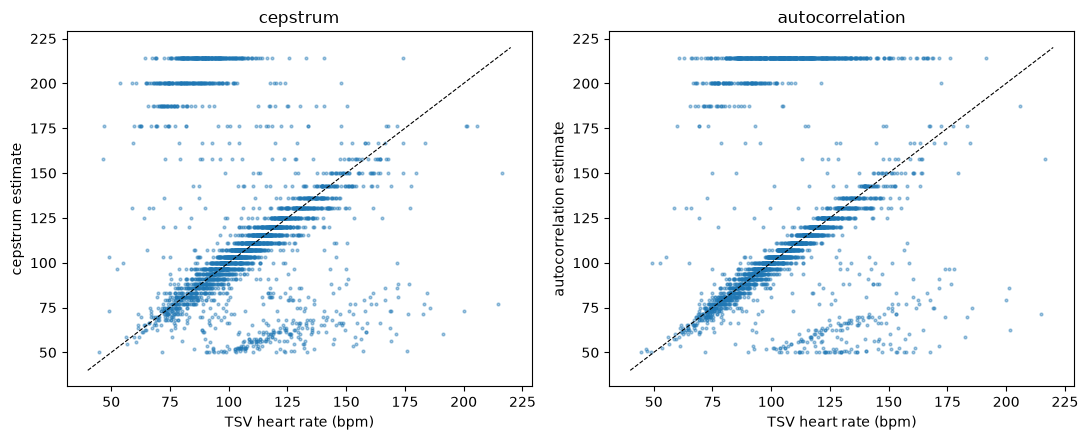

,method,MAE (bpm),median AE (bpm),within 10 bpm
0,cepstrum of homomorphic envelope,26.799244,5.044170,0.673624
1,autocorrelation of envelope,32.205792,4.062785,0.657812


In [5]:
v = df.dropna(subset=["heart_rate_tsv"])
err_c = np.abs(v.ceps_bpm - v.heart_rate_tsv)
err_a = np.abs(v.acf_bpm - v.heart_rate_tsv)
hr_tab = pd.DataFrame({
    "method": ["cepstrum of homomorphic envelope", "autocorrelation of envelope"],
    "MAE (bpm)": [err_c.mean(), err_a.mean()],
    "median AE (bpm)": [err_c.median(), err_a.median()],
    "within 10 bpm": [(err_c < 10).mean(), (err_a < 10).mean()],
})
hr_tab.to_csv(P["tables"] / "04_heart_rate_validation.csv", index=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, col, name in zip(ax, ["ceps_bpm", "acf_bpm"], ["cepstrum", "autocorrelation"]):
    a.scatter(v.heart_rate_tsv, v[col], s=4, alpha=0.4); a.plot([40, 220], [40, 220], "k--", lw=0.8)
    a.set_xlabel("TSV heart rate (bpm)"); a.set_ylabel(f"{name} estimate"); a.set_title(name)
plt.tight_layout(); savefig(fig, "04_heart_rate_scatter"); plt.show()
hr_tab

## 4. Cross-spectral density & coherence between auscultation sites of one patient
The four sites are recorded **sequentially**, not simultaneously, so time-domain coherence
between sites is expected to be low; coherence is therefore computed between the two halves
of the *same* recording (stationarity of the heart-sound spectrum) and between sites.

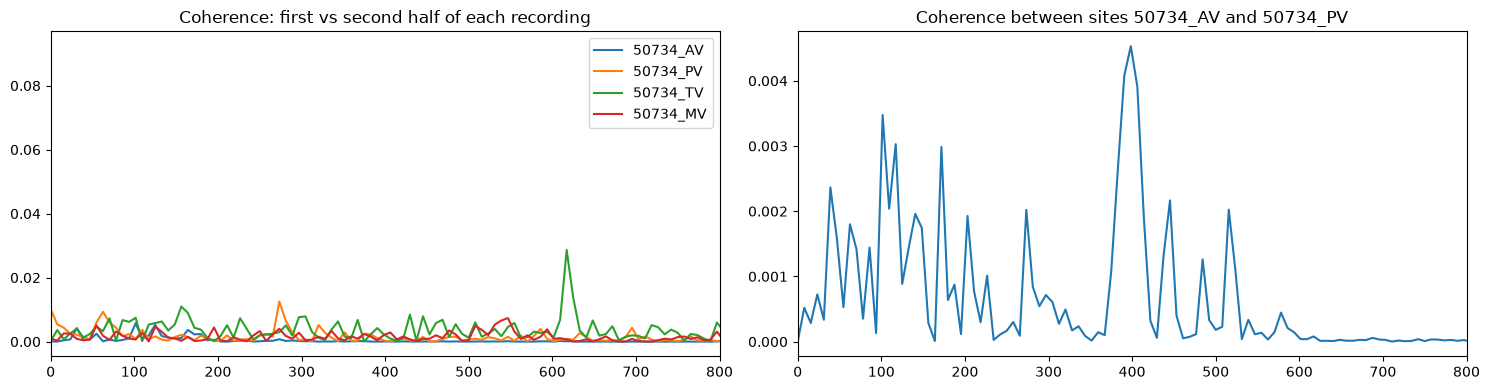

In [6]:
pid = df.groupby("patient_id").location.nunique().idxmax()
recs = df[df.patient_id == pid].record_id.tolist()[:4]
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for r in recs:
    s = sig[r].astype(np.float32); h = len(s) // 2
    fc, cxy = coherence(s[:h], s[h:], fs, 256)
    ax[0].plot(fc, cxy, label=r)
ax[0].set_title("Coherence: first vs second half of each recording"); ax[0].set_xlim(0, 800); ax[0].legend()
a, b = sig[recs[0]].astype(np.float32), sig[recs[1]].astype(np.float32)
fc, cxy = coherence(a, b, fs, 256)
ax[1].plot(fc, cxy); ax[1].set_xlim(0, 800); ax[1].set_title(f"Coherence between sites {recs[0]} and {recs[1]}")
plt.tight_layout(); savefig(fig, "04_coherence"); plt.show()

## 5. PCA of the state descriptors and ICA source separation

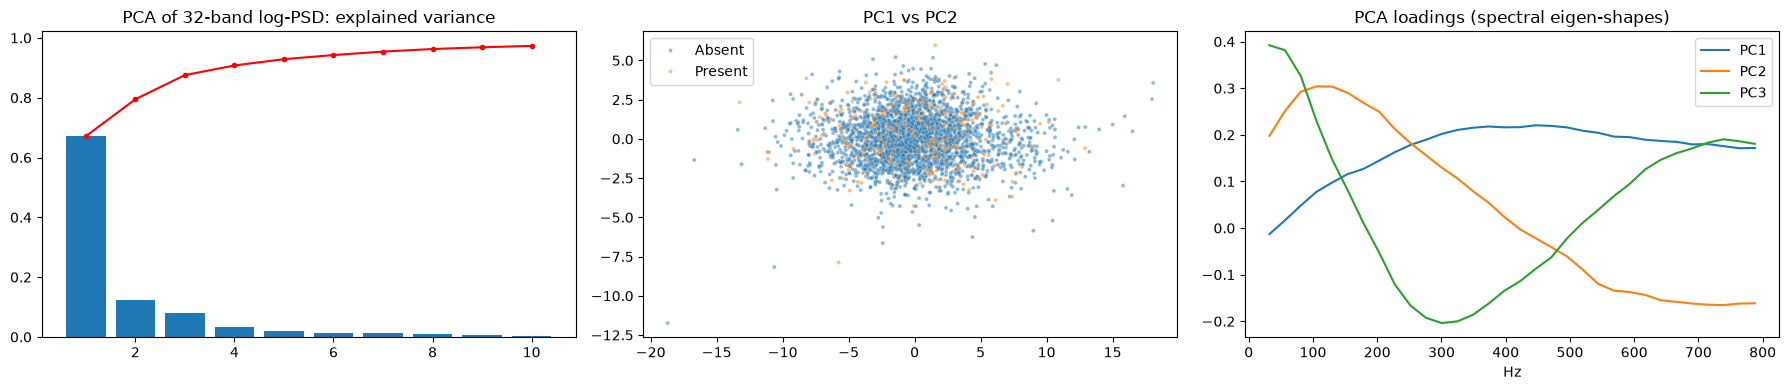

In [7]:
from sklearn.preprocessing import RobustScaler
cols = [c for c in df.columns if c.startswith("logpsd_")]
Z = RobustScaler().fit_transform(np.nan_to_num(lab[cols].values))
pca = PCA(10).fit(Z)
pcs = pca.transform(Z)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].bar(range(1, 11), pca.explained_variance_ratio_); ax[0].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_), "r.-")
ax[0].set_title("PCA of 32-band log-PSD: explained variance")
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=lab.murmur_label.values, s=8, alpha=0.5, ax=ax[1]); ax[1].set_title("PC1 vs PC2")
fb = np.linspace(20, 800, 33); fc_ = (fb[:-1] + fb[1:]) / 2
for i in range(3):
    ax[2].plot(fc_, pca.components_[i], label=f"PC{i + 1}")
ax[2].legend(); ax[2].set_xlabel("Hz"); ax[2].set_title("PCA loadings (spectral eigen-shapes)")
plt.tight_layout(); savefig(fig, "04_pca"); plt.show()

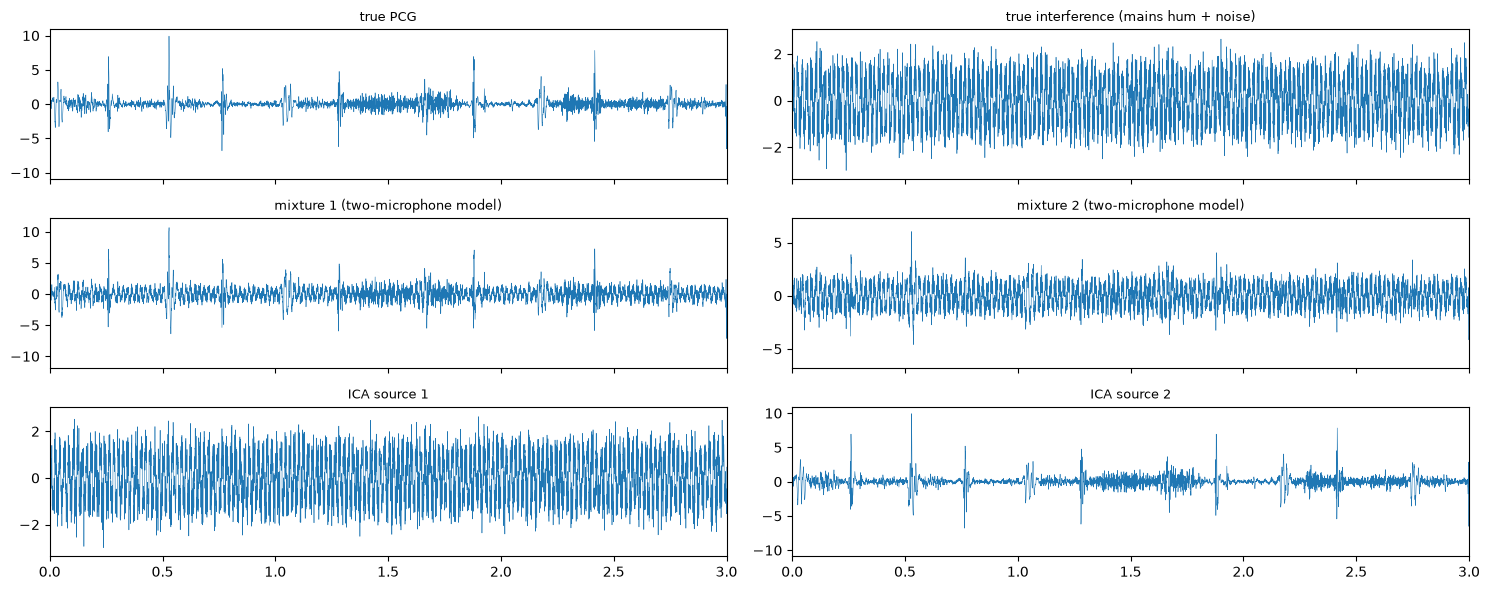

|corr(true, ICA)| matrix:
 [[0.007 1.   ]
 [1.    0.011]]


In [8]:
rng = np.random.default_rng(0)
s1 = sig[lab.record_id.iloc[5]].astype(np.float32)[: 8 * fs]
tt = np.arange(len(s1)) / fs
s2 = (0.6 * np.sign(np.sin(2 * np.pi * 50 * tt)) + 0.4 * rng.standard_normal(len(tt))).astype(np.float32)
S_true = np.c_[s1 / s1.std(), s2 / s2.std()]
A = np.array([[1.0, 0.7], [0.5, 1.0]])
X = S_true @ A.T
ica = FastICA(2, whiten="unit-variance", random_state=0)
S_est = ica.fit_transform(X)
corr = np.abs(np.corrcoef(S_true.T, S_est.T)[:2, 2:])
fig, ax = plt.subplots(3, 2, figsize=(15, 6), sharex=True)
for j in range(2):
    ax[0, j].plot(tt, S_true[:, j], lw=0.4); ax[0, j].set_title(["true PCG", "true interference (mains hum + noise)"][j], fontsize=9)
    ax[1, j].plot(tt, X[:, j], lw=0.4); ax[1, j].set_title(f"mixture {j + 1} (two-microphone model)", fontsize=9)
    ax[2, j].plot(tt, S_est[:, j], lw=0.4); ax[2, j].set_title(f"ICA source {j + 1}", fontsize=9)
plt.xlim(0, 3); plt.tight_layout(); savefig(fig, "04_ica"); plt.show()
print("|corr(true, ICA)| matrix:\n", corr.round(3))

## 6. Time–frequency image processing: enhancement, Otsu segmentation, cardiac-phase energy, GLCM texture

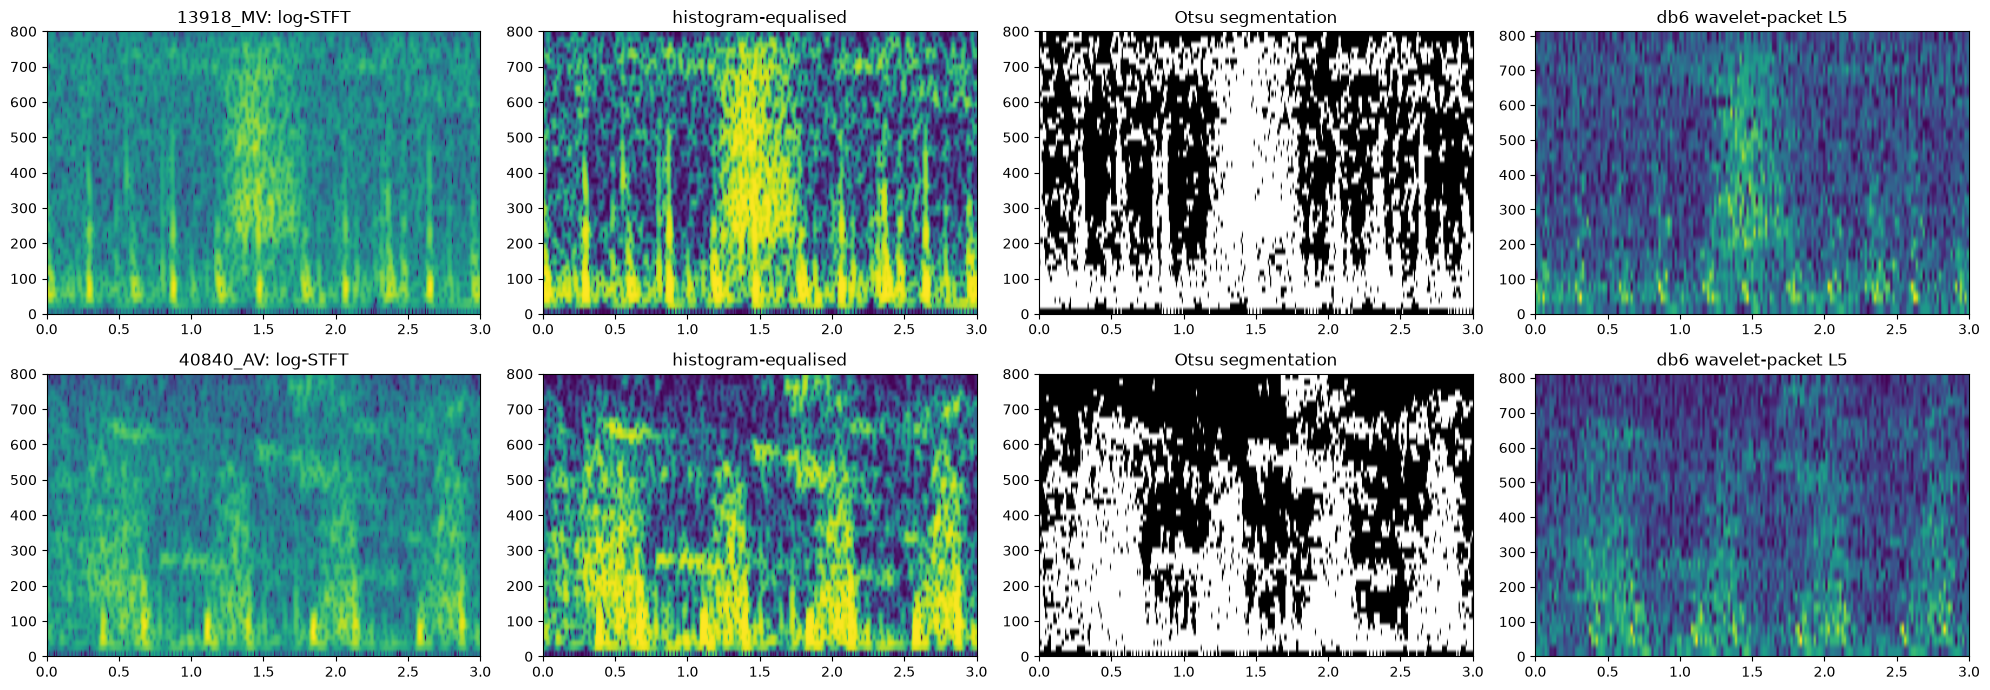

In [9]:
def otsu(img):
    hist, edges = np.histogram(img.ravel(), 256)
    p = hist / hist.sum(); c = (edges[:-1] + edges[1:]) / 2
    w0 = np.cumsum(p); m0 = np.cumsum(p * c); mt = m0[-1]
    sb = (mt * w0 - m0) ** 2 / (w0 * (1 - w0) + 1e-12)
    return c[np.argmax(sb)]


def hist_equalize(img, bins=256):
    h, e = np.histogram(img.ravel(), bins)
    cdf = np.cumsum(h) / h.sum()
    return np.interp(img.ravel(), e[:-1], cdf).reshape(img.shape)


def glcm_features(img, levels=16):
    qimg = np.floor((img - img.min()) / (np.ptp(img) + 1e-12) * (levels - 1)).astype(int)
    g = np.zeros((levels, levels))
    np.add.at(g, (qimg[:, :-1].ravel(), qimg[:, 1:].ravel()), 1)
    g = g + g.T; g /= g.sum()
    i, j = np.indices(g.shape)
    return {"contrast": float((g * (i - j) ** 2).sum()), "homogeneity": float((g / (1 + np.abs(i - j))).sum()),
            "energy": float((g ** 2).sum()), "entropy": float(-(g[g > 0] * np.log2(g[g > 0])).sum())}


def phase_masks(rid, n_frames, hop):
    row = df[df.record_id == rid].iloc[0]
    seg = read_tsv(P["raw"] / row.tsv_path)
    span = annotated_span(seg)
    t = np.arange(n_frames) * hop / fs + (span[0] if span else 0)
    lab_t = np.zeros(n_frames, int)
    for a, b, l in seg:
        lab_t[(t >= a) & (t < b)] = int(l)
    return lab_t


examples = [lab[lab.murmur_label == "Absent"].record_id.iloc[2], lab[(lab.murmur_label == "Present") & (lab.sys_grading == "III/VI")].record_id.iloc[0]]
fig, ax = plt.subplots(2, 4, figsize=(20, 7))
for r_i, rid in enumerate(examples):
    x = sig[rid].astype(np.float32)[: 3 * fs]
    fq, Pw = stft_power(x, fs, 128, 16)
    img = np.log(Pw[fq <= 800] + 1e-6)
    eq = hist_equalize(img)
    thr = otsu(eq)
    ax[r_i, 0].imshow(img, origin="lower", aspect="auto", extent=[0, 3, 0, 800]); ax[r_i, 0].set_title(f"{rid}: log-STFT")
    ax[r_i, 1].imshow(eq, origin="lower", aspect="auto", extent=[0, 3, 0, 800]); ax[r_i, 1].set_title("histogram-equalised")
    ax[r_i, 2].imshow(eq > thr, origin="lower", aspect="auto", extent=[0, 3, 0, 800], cmap="gray"); ax[r_i, 2].set_title("Otsu segmentation")
    M = wavelet_packet_matrix(x[: (len(x) // 32) * 32], "db6", 5)
    ax[r_i, 3].imshow(log_compress(M[:26]), origin="lower", aspect="auto", extent=[0, 3, 0, 812]); ax[r_i, 3].set_title("db6 wavelet-packet L5")
plt.tight_layout(); savefig(fig, "04_tf_image_processing"); plt.show()

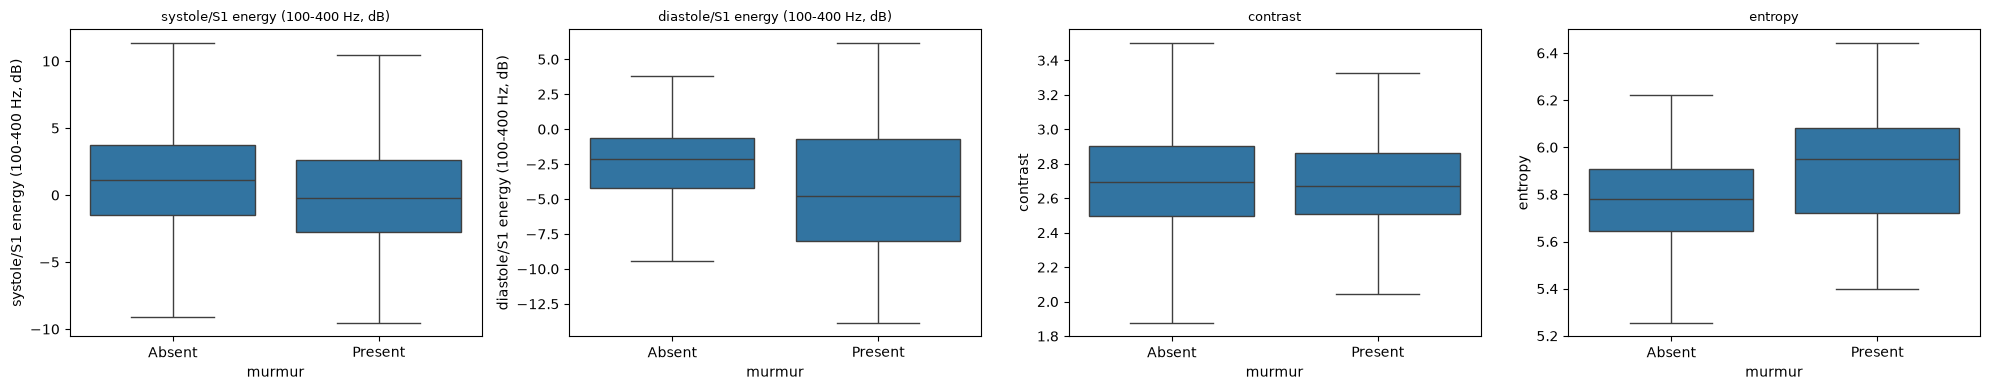

,feature,AUROC (Present vs Absent),"separability max(AUC, 1-AUC)",higher in
2,Otsu foreground fraction,0.285963,0.714037,Absent
5,energy,0.287365,0.712635,Absent
6,entropy,0.692171,0.692171,Present
1,"diastole/S1 energy (100-400 Hz, dB)",0.365753,0.634247,Absent
0,"systole/S1 energy (100-400 Hz, dB)",0.410008,0.589992,Absent
4,homogeneity,0.466159,0.533841,Absent
3,contrast,0.492328,0.507672,Absent


In [10]:
rows = []
for rid in lab.record_id.sample(min(600, len(lab)), random_state=0):
    x = sig[rid].astype(np.float32)
    fq, Pw = stft_power(x, fs, 128, 32)
    ph = phase_masks(rid, Pw.shape[1], 32)
    img = np.log(Pw[fq <= 800] + 1e-6)
    band = (fq >= 100) & (fq <= 400)
    e_sys = Pw[band][:, ph == 2].mean() if (ph == 2).any() else np.nan
    e_dia = Pw[band][:, ph == 4].mean() if (ph == 4).any() else np.nan
    e_s1 = Pw[band][:, ph == 1].mean() if (ph == 1).any() else np.nan
    eq = hist_equalize(img)
    rows.append({"record_id": rid, "murmur": lab.set_index("record_id").murmur_label[rid],
                 "systole/S1 energy (100-400 Hz, dB)": 10 * np.log10(e_sys / e_s1),
                 "diastole/S1 energy (100-400 Hz, dB)": 10 * np.log10(e_dia / e_s1),
                 "Otsu foreground fraction": float((eq > otsu(eq)).mean()), **glcm_features(img)})
tex = pd.DataFrame(rows).dropna()
feat_cols = [c for c in tex.columns if c not in ("record_id", "murmur")]
auc = [roc_auc_score(tex.murmur == "Present", tex[c]) for c in feat_cols]
sep = pd.DataFrame({"feature": feat_cols, "AUROC (Present vs Absent)": auc,
                    "separability max(AUC, 1-AUC)": np.maximum(auc, 1 - np.array(auc)),
                    "higher in": ["Present" if a > 0.5 else "Absent" for a in auc]}).sort_values("separability max(AUC, 1-AUC)", ascending=False)
sep.to_csv(P["tables"] / "04_image_feature_separability.csv", index=False)
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for a, c in zip(ax, ["systole/S1 energy (100-400 Hz, dB)", "diastole/S1 energy (100-400 Hz, dB)", "contrast", "entropy"]):
    sns.boxplot(data=tex, x="murmur", y=c, ax=a, showfliers=False); a.set_title(c, fontsize=9)
plt.tight_layout(); savefig(fig, "04_phase_energy_texture"); plt.show()
sep